# Эксперименты
**Обучение на сырых данных** 
- Score: $1965.98$

**Логарифмирование таргета**
- Score: $2079.75$
- Effect: $+113.78$
- Не будем использовать

**Понижение размерности с помощью численных фич PCA**
- Score: $1987.15$
- Effect: $+21.17$
- Не будем использовать

**Добавление кластерных фич**
- Score: $1967.68$
- Effect: $+1.7$
- Не будем использовать

**Генерация полиномиальных фич из числовых**
- Score: $1963.04$
- Effect: $-2.94$
- Используем

**Генерация парных категориальных фич**
- Score: $1953.07$
- Effect: $-9.97$ (Считая, что `PolyFeatures` Используется)
- Используем

**Использование целевой функции в качестве лосса**
- Score: $1986.98$
- Effect: $+21$
- Не будем использовать

**Удаление фичей с малым количеством сплитов, чем случайные**
- Score: $1948.93$
- Effect: $-4.1$
- Используем

**Ансамблирование моделей на разных порядках значения таргета**
- Score: $2096.9$
- Effect: $+147.97$
- Не будем использовать

**Присвоение больших весов объектам с большим таргетом на трейне**
- Score: $1948.0$
- Effect: $-0.93$
- Не будем использовать

In [1]:
from itertools import combinations
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from umap import UMAP

from matplotlib import pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.axes import Axes
import seaborn as sns

import lightgbm as lgb

import warnings

warnings.filterwarnings("ignore")

# reproducibility
SEED = 0
np.random.seed(SEED)

In [2]:
df_train = pd.read_csv("aim-2025-something-mysterious/train_contest.csv")
df_test = pd.read_csv("aim-2025-something-mysterious/test_contest.csv")
sample_submission = pd.read_csv("aim-2025-something-mysterious/sample_submission.csv")

df_train, df_val = train_test_split(df_train, test_size=0.2, random_state=SEED)

x_train: pd.DataFrame = df_train.drop(columns=["target"])
y_train: pd.DataFrame = df_train["target"]
x_val: pd.DataFrame = df_val.drop(columns=["target"])
y_val: pd.DataFrame = df_val["target"]
x_test = df_test.drop(columns=["index"])

## Распределение таргетной фичи

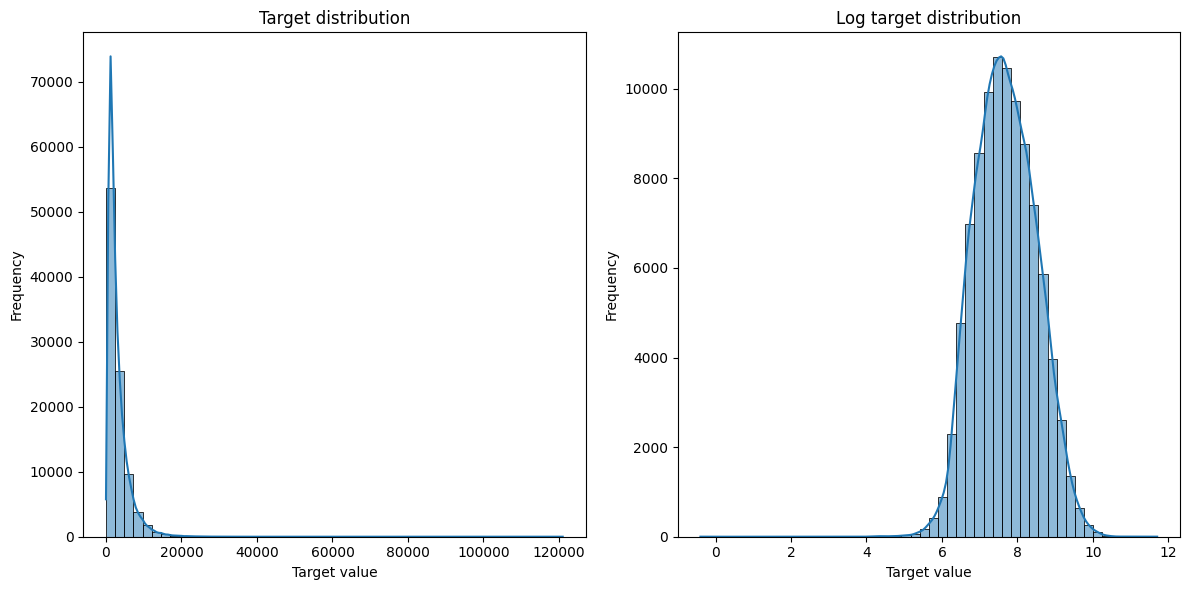

In [3]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

for i, target in enumerate([y_train, np.log(y_train)]):
    sns.histplot(target, bins=50, kde=True, ax=ax[i])
    ax[i].set_title("Target distribution" if i == 0 else "Log target distribution")
    ax[i].set_xlabel("Target value")
    ax[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [4]:
# Закомментировано, так как не помогло
# y_train = np.log(y_train)
# y_val = np.log(y_val)

Из графиков видно, что распределение логарифма таргета похоже на нормальное, и имеет намного менее тяжёлый хвост, так что логарифмирование таргета может помочь.

Эмпирические эксперименты показали, что логарифмирование ухудшает качество, так что не будем делать это

## Препроцессинг

In [5]:
cat_features = df_train.select_dtypes(exclude=["number"]).columns.tolist()
num_features = df_train.select_dtypes(include=["number"]).columns.tolist()
num_features.remove("target")
all_features = cat_features + num_features

encoder = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            cat_features,
        ),
    ],
    remainder="passthrough",
)

x_train = pd.DataFrame(encoder.fit_transform(x_train), columns=x_train.columns)
x_val = pd.DataFrame(encoder.transform(x_val), columns=x_val.columns)
x_test = pd.DataFrame(encoder.transform(x_test), columns=x_test.columns)

x_train[cat_features] = x_train[cat_features].astype(np.int32)
x_val[cat_features] = x_val[cat_features].astype(np.int32)
x_test[cat_features] = x_test[cat_features].astype(np.int32)

## Понижение размерности (5 баллов)
Применим `UMAP` к численным фичам из обучающей выборки 

In [6]:
umap = UMAP(n_components=2, init="pca")
high_dim = x_train[num_features].values

embedding = umap.fit_transform(high_dim)
embedding_df = pd.DataFrame(embedding, columns=["x", "y"])

embedding_df["target"] = y_train.values

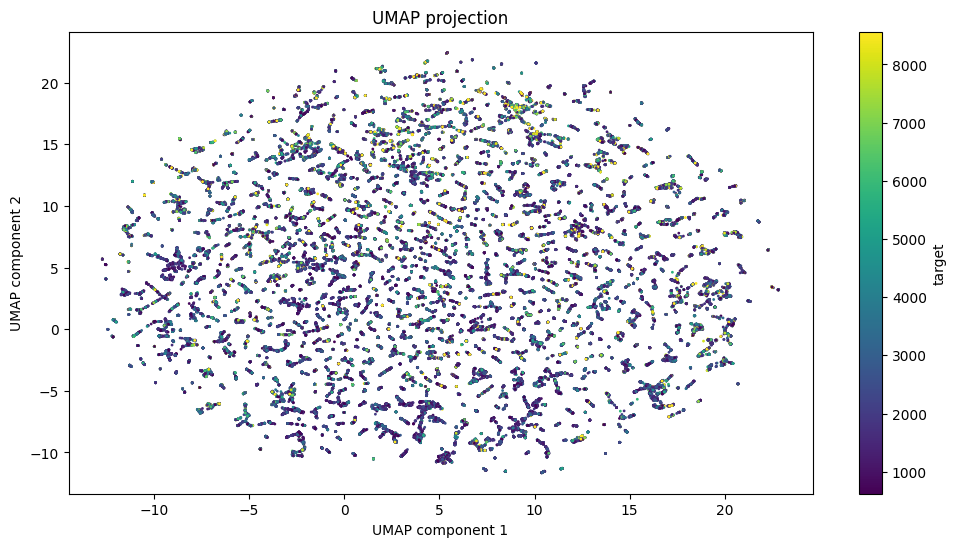

In [7]:

norm = Normalize(vmin=y_train.quantile(0.05), vmax=y_train.quantile(0.95))

plt.figure(figsize=(12, 6))
plt.scatter(
    embedding_df["x"],
    embedding_df["y"],
    c=embedding_df["target"],
    cmap="viridis",
    norm=norm,
    s=1,
)
plt.colorbar(label="target")
plt.title("UMAP projection")
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.show()

Низкоразмерное представление данных почти не имеет какой-либо структуры, точки как будто равномерно распределены по шару. Наблюдаются мелкие кластеры, но их слишком много, так что вряд ли кластеризация существенно улучшит качество модели.

Для генерации фичей понижением размерности можно попробовать `PCA`

In [8]:
feats_to_decompose = num_features

pca = PCA(n_components=0.9)
pca.fit(x_train[feats_to_decompose])

# Скор ухудшился, так что закомментировано
# components_train = pd.DataFrame(pca.transform(x_train[num_features]), columns=pca.get_feature_names_out())
# components_val = pd.DataFrame(pca.transform(x_val[num_features]), columns=pca.get_feature_names_out())
# components_test = pd.DataFrame(pca.transform(x_test[num_features]), columns=pca.get_feature_names_out())

# num_features = components_train.columns.tolist()
# all_features = cat_features + num_features

# x_train = pd.concat([x_train, components_train], axis=1)
# x_val = pd.concat([x_val, components_val], axis=1)
# x_test = pd.concat([x_test, components_test], axis=1)

PCA(n_components=0.9)

## Кластеризация (5 баллов)
Из `UMAP`-эмбеддингов видно, что примеры распределены почти равномерно, но есть куча маленьких кластеров. Не будем делать настолько много кластеров, но попробуем добавить их как фичи

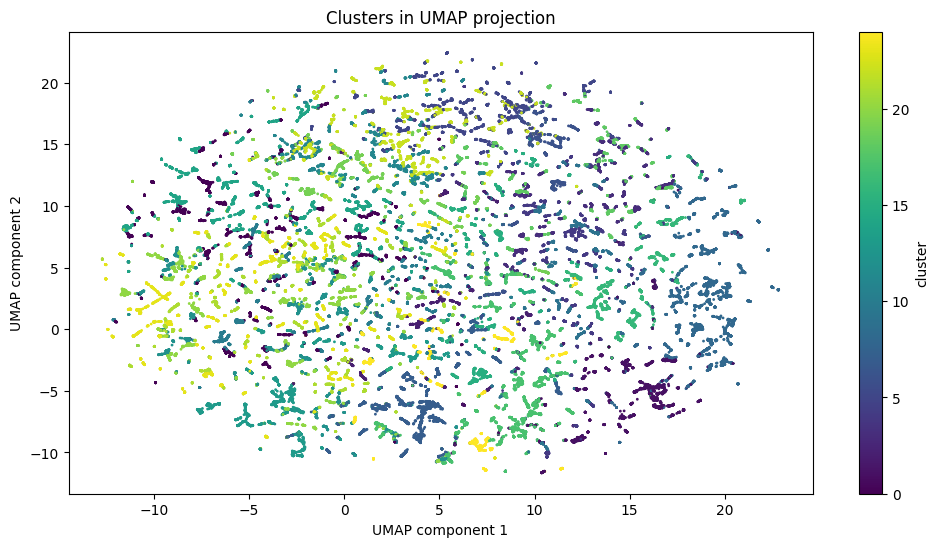

In [9]:
kmeans = KMeans(n_clusters=25, random_state=SEED)
kmeans.fit(x_train[num_features].values)

embedding_df["cluster"] = kmeans.labels_
plt.figure(figsize=(12, 6))
plt.scatter(
    embedding_df["x"],
    embedding_df["y"],
    c=embedding_df["cluster"],
    s=1,
)
plt.colorbar(label="cluster")
plt.title("Clusters in UMAP projection")
plt.xlabel("UMAP component 1")
plt.ylabel("UMAP component 2")
plt.show()

Как и ожидалось, кластеризация не помогла, так что не будем использовать её

In [10]:
# x_train["cluster"] = kmeans.predict(x_train[num_features].values)
# x_val["cluster"] = kmeans.predict(x_val[num_features].values)
# x_test["cluster"] = kmeans.predict(x_test[num_features].values)

# cat_features.append("cluster")
# all_features.append("cluster")

## Генерация фич (5 баллов)

У нас довольно много бинарных фич, которые, как будет видно чуть позже по ноутбуку, не так важны для модели по отдельности. Так как они могут обозначать вхождение в какие-либо категории, можно попробовать добавить фичу с числом таких вхождений. Как показывали эксперименты на валидиционной выборке, скор от этого улучшается

In [11]:
cat_features_nuniques = x_train[cat_features].nunique()
binary_features = cat_features_nuniques[cat_features_nuniques == 2].index.tolist()

name = "binary_cat_count"
x_train[name] = x_train[binary_features].sum(axis=1).astype(np.float32)
x_val[name] = x_val[binary_features].sum(axis=1).astype(np.float32)
x_test[name] = x_test[binary_features].sum(axis=1).astype(np.float32)

num_features.append(name)
all_features.append(name)

У нас не так много числовых фич, так что можно попробовать сгенерировать их сочетания с помощью `PolynomialFeatures`

In [12]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
poly.fit(x_train[num_features])

poly_features_train = poly.transform(x_train[num_features])
poly_features_val = poly.transform(x_val[num_features])
poly_features_test = poly.transform(x_test[num_features])

poly_feature_names = poly.get_feature_names_out(num_features).tolist()
poly_feature_names = list(map(lambda x: "_".join(x.split(" ")), poly_feature_names))

x_train[poly_feature_names] = poly_features_train
x_val[poly_feature_names] = poly_features_val
x_test[poly_feature_names] = poly_features_test

In [13]:
num_features = poly_feature_names
all_features = cat_features + num_features

Также можно попробовать сгенерировать парные категориальные фичи по аналогии с `PolynomialFeatures`. Для этого выберем 25 наименее разнообразных небинарных (потому что уже есть фича с их комбинацией) категориальных фичей и сгенерируем их комбинации

In [14]:
features_to_pair = (
    cat_features_nuniques.drop(binary_features).sort_values()[:25].index.tolist()
)


for feat1, feat2 in combinations(features_to_pair, 2):
    name = f"{feat1}_{feat2}"
    multiplier = cat_features_nuniques[feat2]
    x_train[name] = x_train[feat1] * multiplier + x_train[feat2]
    x_val[name] = x_val[feat1] * multiplier + x_val[feat2]
    x_test[name] = x_test[feat1] * multiplier + x_test[feat2]
    cat_features.append(name)
    all_features.append(name)

## Свои функции лосса и метрики (5 баллов)
Определим функцию лосса `loss_fn`, которая будет выдавать векторы градиентов и гессианов для каждого примера по предсказаниям, а также функцию метрики `metric_fn`, которая будет выдавать скор для более точной ранней остановки

In [15]:
def loss_fn(label: np.ndarray, pred: np.ndarray) -> float:
    eps = 100
    alpha = 1.2
    beta = 0.9

    grad = np.zeros_like(pred)
    hess = np.zeros_like(pred)

    mask = pred > label + eps
    grad[mask] = 2 * alpha * (pred[mask] - label[mask] - eps)
    hess[mask] = 2 * alpha

    mask = pred < label - eps
    grad[mask] = 2 * beta * (pred[mask] - label[mask] + eps)
    hess[mask] = 2 * beta

    return grad, hess


def metric_fn(label: np.ndarray, pred: np.ndarray) -> float:
    eps = 100
    alpha = 1.2
    beta = 0.9

    losses = np.zeros_like(pred)

    mask = pred > label + eps
    losses[mask] = alpha * (pred[mask] - label[mask] - eps) ** 2

    mask = pred < label - eps
    losses[mask] = beta * (pred[mask] - label[mask] + eps) ** 2

    return "assym_loss", np.sqrt(np.mean(losses)), False

Как показала практика, использование своих функций лосса и метрики не дало прироста качества, так что не будем использовать их в финальной модели

## Обучение модели

In [16]:
model = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
    # objective=loss_fn, - скор ухудшился
)

model.fit(
    x_train[all_features],
    y_train,
    eval_set=[(x_val[all_features], y_val)],
    # eval_metric=metric_fn, - скор ухудшился
    eval_metric="rmse",
    categorical_feature=cat_features,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.062071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 35203
[LightGBM] [Info] Number of data points in the train set: 96075, number of used features: 534
[LightGBM] [Info] Start training from score 3052.070620
Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2292.95	valid_0's l2: 5.25764e+06
[10]	valid_0's rmse: 2072.38	valid_0's l2: 4.29476e+06
[15]	valid_0's rmse: 1969.07	valid_0's l2: 3.87725e+06
[20]	valid_0's rmse: 1917.94	valid_0's l2: 3.6785e+06
[25]	valid_0's rmse: 1886.23	valid_0's l2: 3.55787e+06
[30]	valid_0's rmse: 1868.93	valid_0's l2: 3.49291e+06
[35]	valid_0's rmse: 1856.51	valid_0's l2: 3.44664e+06
[40]	valid_0's rmse: 1848.24	valid_0's l2: 3.416e+06
[45]	valid_0's rmse: 1841.29	valid_0's l2: 3.39036e+06
[50]	valid_0's rmse: 1837.17	valid_0'

LGBMRegressor(n_estimators=1000, random_state=0)

In [17]:
preds = model.predict(x_test[all_features])
# preds = np.exp(preds) - логарифмирование таргета не помогло
sample_submission["target"] = preds
sample_submission.to_csv("submission.csv", index=False)

## Интерпретация модели (5 баллов)
Посмотрим на значимость фичей в модели

In [18]:
model.importance_type = "split"
fi = pd.DataFrame(
    {
        "feature": model.feature_name_,
        "importance": model.feature_importances_,
    }
)
fi.sort_values("importance", ascending=False, inplace=True)
fi.reset_index(drop=True, inplace=True)
fi

,feature,importance
0,cat116,336
1,cat112,170
2,cat113,142
3,cont2_binary_cat_count,136
4,cont2_cont7,134
...,...,...
531,cat46,0
532,cat93_cat97,0
533,cat93_cat94,0
534,cat93_cat96,0


В данных огромное количество фич, некоторые из них вообще не использовались моделью. Перед тем, как их отбирать с помощью других методов, для большей эффективности следует отсеять заведомо ненужные фичи.

In [19]:

num_features_pruned = fi[(fi["importance"] > 5) & (fi["feature"].isin(num_features))][
    "feature"
].tolist()
cat_features_pruned = fi[(fi["importance"] > 5) & (fi["feature"].isin(cat_features))][
    "feature"
].tolist()
all_features_pruned = cat_features_pruned + num_features_pruned
print(f"Original features: {len(all_features)}")
print(f"Pruned features: {len(all_features_pruned)}")

Original features: 536
Pruned features: 155


In [20]:
model_pruned = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
    # objective=loss_fn, - скор ухудшился
)

model_pruned.fit(
    x_train[all_features_pruned],
    y_train,
    eval_set=[(x_val[all_features_pruned], y_val)],
    # eval_metric=metric_fn, - скор ухудшился
    eval_metric="rmse",
    categorical_feature=cat_features_pruned,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055024 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21602
[LightGBM] [Info] Number of data points in the train set: 96075, number of used features: 155
[LightGBM] [Info] Start training from score 3052.070620
Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2293.1	valid_0's l2: 5.25832e+06
[10]	valid_0's rmse: 2073.75	valid_0's l2: 4.30046e+06
[15]	valid_0's rmse: 1971.84	valid_0's l2: 3.88816e+06
[20]	valid_0's rmse: 1917.52	valid_0's l2: 3.67689e+06
[25]	valid_0's rmse: 1886.35	valid_0's l2: 3.5583e+06
[30]	valid_0's rmse: 1866.85	valid_0's l2: 3.48511e+06
[35]	valid_0's rmse: 1854.81	valid_0's l2: 3.44032e+06
[40]	valid_0's rmse: 1846.82	valid_0's l2: 3.41074e+06
[45]	valid_0's rmse: 1841.21	valid_0's l2: 3.39005e+06
[50]	valid_0's rmse: 1837.54	valid_0's l2: 3.37655e+06
[55]	valid_0's rmse: 1835.02	valid_0's l2: 3.

LGBMRegressor(n_estimators=1000, random_state=0)

Такой небольшой прунинг в одиночку не показал прироста качества, но эмпирические эксперименты показали, что последующие шаги лучше работают с меньшим количеством фичей, более того, в соревновании это предсказание даёт небольшой прирост качества, так что оставим его.

In [21]:
preds = model_pruned.predict(x_test[all_features_pruned])
sample_submission["target"] = preds
sample_submission.to_csv("submission_pruned_features.csv", index=False)

In [22]:
shap_values = model_pruned.predict(
    x_train[all_features_pruned],
    pred_contrib=True,
)

Мы уже посмотрели на значимость фичей по сплитам, но также хотелось бы посмотреть на другие значимости

Построим распределение `shap_values`

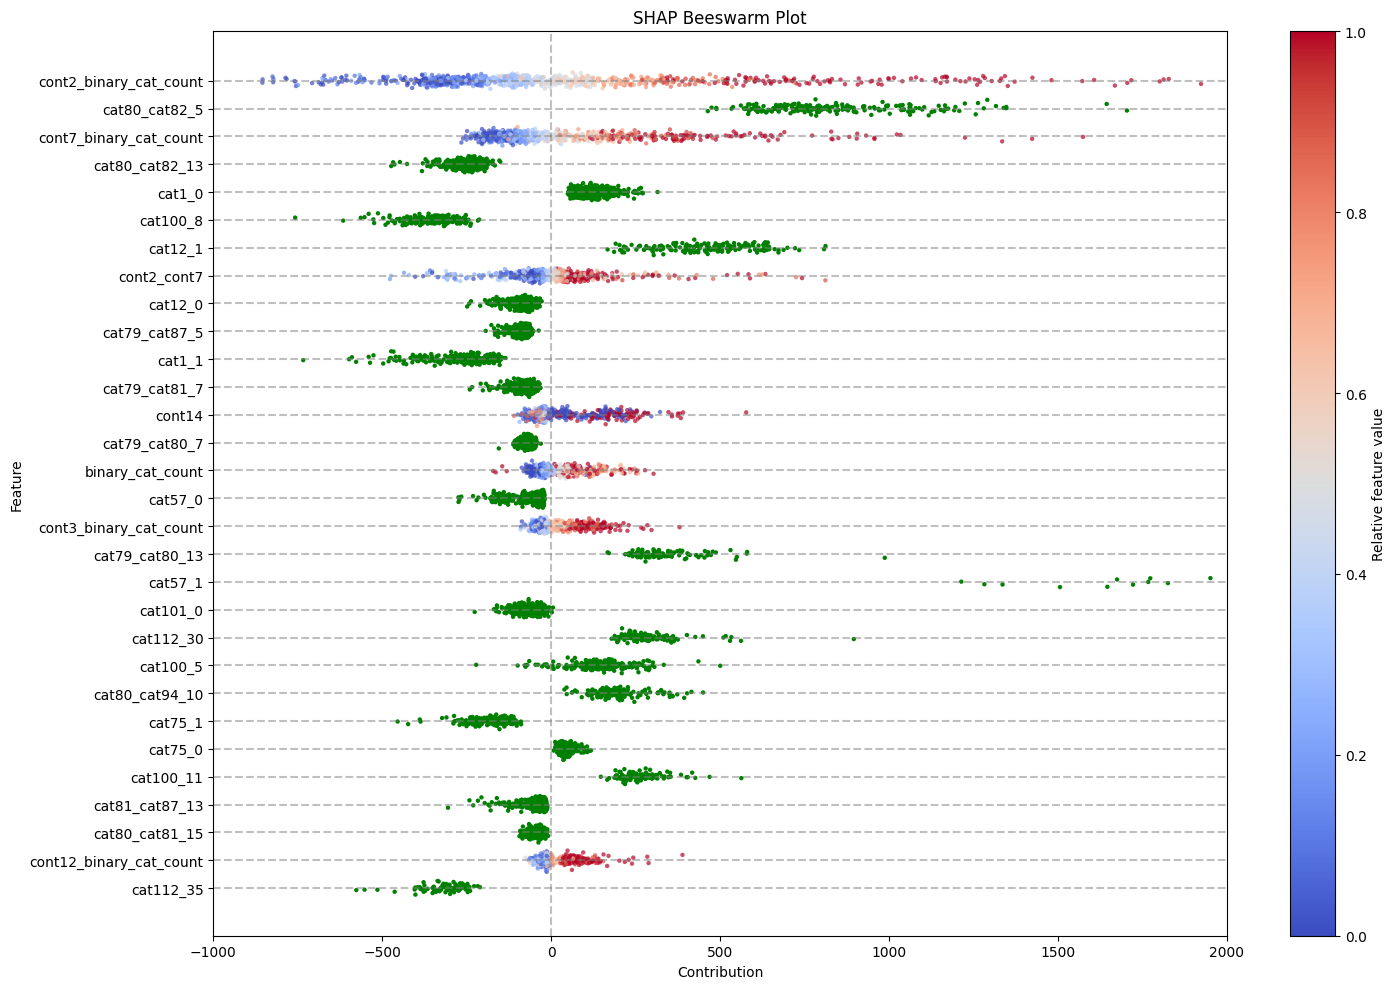

In [23]:
def my_beeswarm(
    shap_values: np.ndarray,
    df: pd.DataFrame,
    features: List[str],
    n_swarms: int,
    figsize: Tuple[int, int] = (13, 6),
    sample_size: int = 1000,
    random_state: int = 42,
    only_numerical: bool = False,
    cat_features: Optional[List[str]] = None,
    shap_limits: Optional[Tuple[float, float]] = None,
):
    """
    Draws a beeswarm plot for SHAP values with point colored based on feature values.
    Sorts features by their contribution (mean absolute SHAP value) and orders corresponding
    strips from top to bottom.

    Numerical and categorical features are inferred automatically,
    numerical features shap values are colored by their original values,
    categorical features are colored uniformly.

    Parameters
    ---
        shap_values: np.ndarray
            Array of SHAP values of shape (N, F+1), N - number of samples, F - number of features.
            The last column is the model mean prediction.
        df: pd.DataFrame
            Original dataframe
        features: List[str]
            List of names of shap values columns (excluding the last column). Must match
            the length of the shap_values array, every feature must be present in the DataFrame.
        n_swarms: int
            Number of strips to plot. Will display n_swarms most important features.
        figsize: Tuple[int, int], optional
            Figure size to be passed to plt.subplots.
        sample_size: int, optional
            Number of points randomly sampled from the original dataset for plotting.
        random_state: int, optional
            Seed for reproducibility.
        cat_features: List[str], optional
            List of categorical features. If not provided, will be inferred from the DataFrame.
        shap_limits: Tuple[float, float], optional
            If provided, will be used to set the x-axis limits of the plot.
            If not provided, will be set to the most extreme 0.1 and 0.9 quantiles of the SHAP values.
    """
    rng = np.random.RandomState(random_state)
    ids = rng.choice(len(df), size=sample_size, replace=False)
    df_sample = df.iloc[ids]
    shap_sample = shap_values[ids]

    shap_values_df = pd.DataFrame(
        shap_sample[:, :-1],
        columns=features,
        index=df_sample.index,  # to make .loc return correct entries
    )
    feature_set = set(features)

    if cat_features is None:
        cat_features = list(
            filter(
                lambda x: x in feature_set,
                df_sample.select_dtypes(exclude=["number"]).columns,
            )
        )

    num_features = list(
        filter(
            lambda x: x in feature_set,
            [feat for feat in df_sample.columns if feat not in cat_features],
        )
    )

    # we will store every stripe data in this list
    # (feature name, shap_values, score, is_categorical)
    # for categorical features, we will treat each unique value as its own "feature"
    # and shap_values will be the values of a single category
    swarms: List[Tuple[str, np.ndarray, float, int]] = []

    for feature in num_features:
        swarms.append(
            (
                feature,
                shap_values_df[feature].values,
                np.mean(np.abs(shap_values_df[feature].values)),
                False,
            )
        )
    if not only_numerical:
        for feature in cat_features:
            unique_vals = df_sample[feature].unique()
            for value in unique_vals:
                mask = df_sample[feature] == value

                # for each distinct category, take its shap values
                vals = shap_values_df.loc[mask, feature].values

                # score is calculated includes zero for samples of different categories
                # this is done because categorical features tend to have large shap values
                score = np.mean(np.abs(shap_values_df[feature] * mask))
                swarms.append(
                    (
                        f"{feature}_{value}",
                        vals,
                        score,
                        True,
                    )
                )

    # take n_swarms best features by score
    swarms = sorted(swarms, key=lambda x: x[2], reverse=True)[:n_swarms]

    fig, ax = plt.subplots(figsize=figsize)

    y_ticks = []
    y_pos = 0
    
    if not shap_limits:
        largest_quantile = -float("inf")
        lowest_quantile = float("inf")
    for name, shap_vals, _, is_categorical in reversed(swarms):
        y_ticks.append(name)
        n_points = len(shap_vals)

        # add noise to y-coordinates to avoid overlapping points
        jitter = rng.normal(0, 0.1, size=n_points)

        # for nan values, reduce jitter to prevent them from overlapping with other points
        if name in num_features:
            na_mask = np.isnan(df_sample[name].values)
            jitter[na_mask] *= 0.25

        y_coords = np.full(n_points, y_pos) + jitter

        if is_categorical:
            colors = ["green"] * n_points
        else:
            # to avoid bias towards outliers, take 0.1 and 0.9 quantiles
            feature_vals = df_sample[name].values
            vmin = np.nanquantile(feature_vals, 0.1)
            vmax = np.nanquantile(feature_vals, 0.9)

            norm = plt.Normalize(vmin=vmin, vmax=vmax)
            cmap = plt.cm.coolwarm
            colors = cmap(norm(feature_vals))
            colors[:, -1] = 0.7  # display NaNs as black points

        if not shap_limits:
            largest_quantile = max(largest_quantile, np.nanquantile(shap_vals, 0.9))
            lowest_quantile = min(lowest_quantile, np.nanquantile(shap_vals, 0.1))
        ax.scatter(shap_vals, y_coords, c=colors, s=10, edgecolor="none")
        y_pos += 1



    ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
    for y in range(len(y_ticks)):
        ax.axhline(y=y, color="gray", linestyle="--", alpha=0.5)

    # set xlim to np.quantile(all_shap_vals, [0.05, 0.95])
    if shap_limits:
        lowest_quantile, largest_quantile = shap_limits
    ax.set_xlim(lowest_quantile, largest_quantile)
    ax.set_yticks(range(len(y_ticks)))
    ax.set_yticklabels(y_ticks)
    ax.set_xlabel("Contribution")
    ax.set_ylabel("Feature")
    ax.set_title("SHAP Beeswarm Plot")

    if num_features:  # works if there is at least one scatterplot with coloring
        sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label("Relative feature value")

    plt.tight_layout()
    plt.show()


my_beeswarm(
    shap_values,
    x_train,
    all_features_pruned,
    n_swarms=30,
    sample_size=1000,
    random_state=SEED,
    figsize=(15, 10),
    cat_features=cat_features_pruned,
    shap_limits=(-1000, 2000)
)

Из графика видно, что объекты одной и той же категории зачастую имеют схожие влияния на итоговые предсказания, причем они почти всегда одного знака и имеют довольно высокую магнитуду, так что модель вполне уверенна в этих фичах. Но видно, что для некоторых численных фичей их значения могут плохо кореллировать с решением модели. 

Построим такой же график только для численных фичей

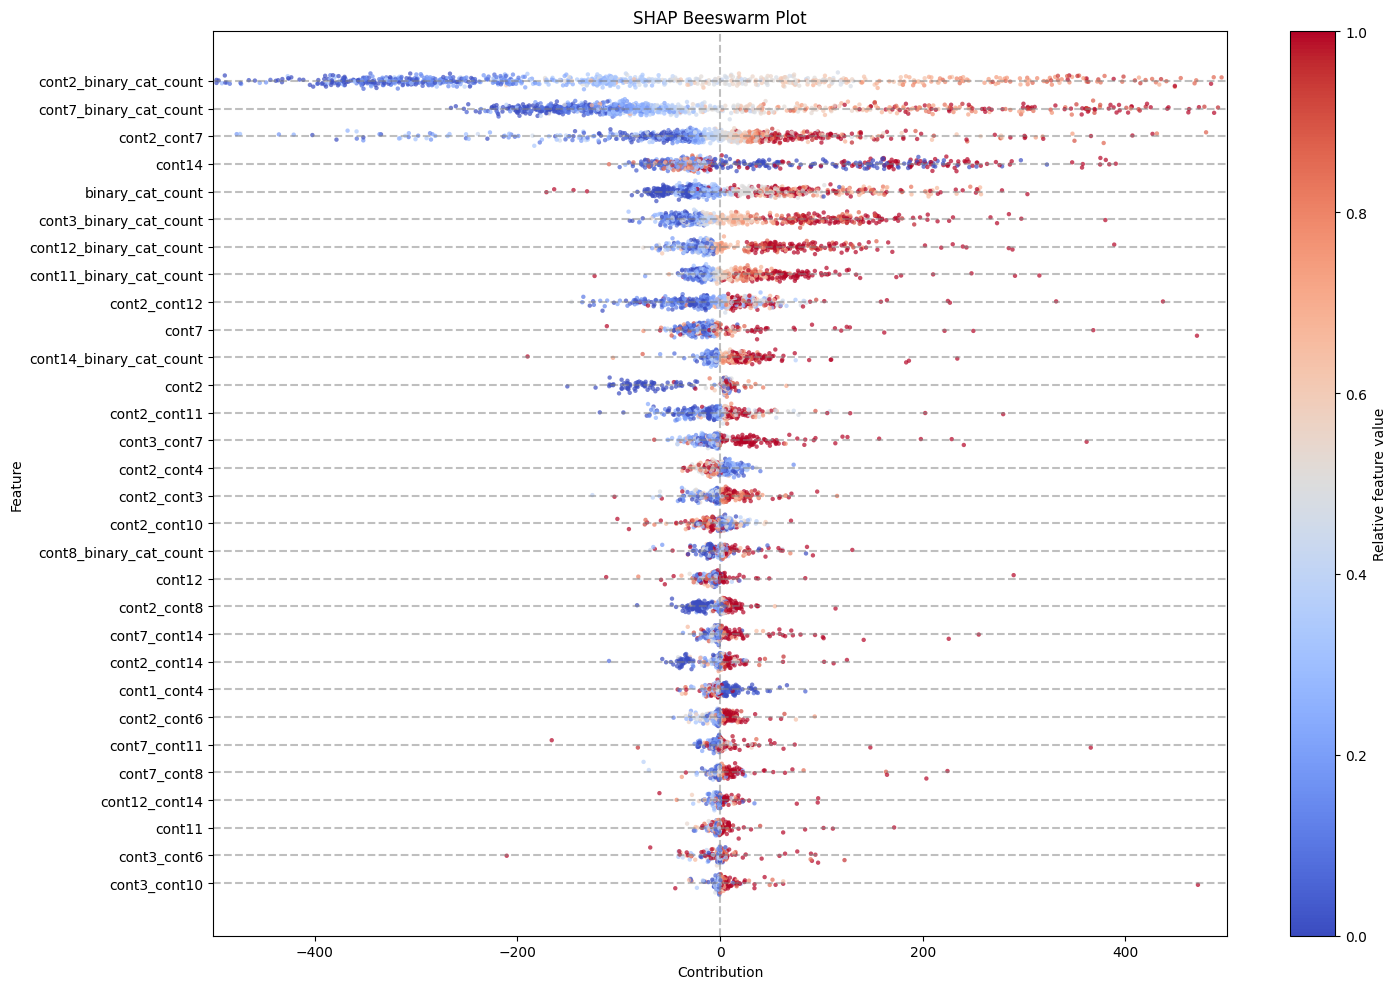

In [24]:
my_beeswarm(
    shap_values,
    x_train,
    all_features_pruned,
    n_swarms=30,
    sample_size=1000,
    random_state=SEED,
    figsize=(15, 10),
    only_numerical=True,
    cat_features=cat_features_pruned,
    shap_limits=(-500, 500)
)

Большинство из самых значимых фичей вполне хорошо коррелируют с предсказаниями модели за некоторыми редкими исключениями

In [25]:
preds = model_pruned.predict(x_train[all_features_pruned])
x_train["pred"] = preds
x_train["residual"] = x_train["pred"] - y_train.values
x_train["target"] = y_train.values

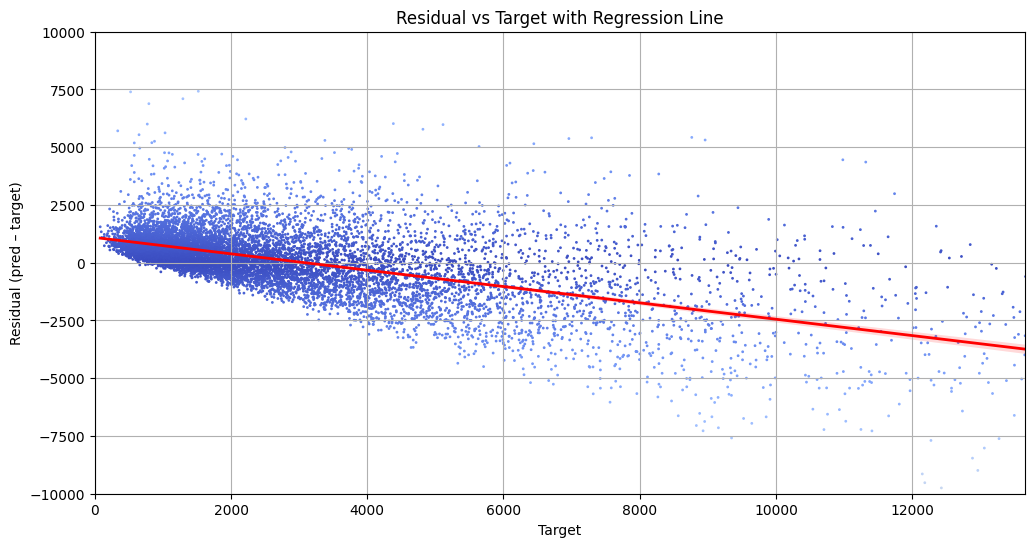

In [26]:
plt.figure(figsize=(12, 6))
data_to_plot = x_train.sample(10000)

# scatter
ax = plt.scatter(
    data_to_plot["target"],
    data_to_plot["pred"] - data_to_plot["target"],
    c=np.abs(data_to_plot["residual"]),
    cmap="coolwarm",
    s=1,
)


sns.regplot(
    x=data_to_plot["target"],
    y=data_to_plot["pred"] - data_to_plot["target"],
    scatter=False,
    color="red",
    line_kws={"linewidth": 2},
)

plt.xlim(0, np.quantile(data_to_plot["target"], 0.99))
plt.ylim(-10000, 10000)
plt.grid()
plt.xlabel("Target")
plt.ylabel("Residual (pred – target)")
plt.title("Residual vs Target with Regression Line")
plt.show()

Ошибка модели почти линейно зависит от значение целевого признака, так что можно попробовать разбить датасет на несколько частей по этому признаку и обучить отдельную модель на каждой из них. 

Но чтобы избежать утечки, для разбиения надо использовать фичу, которая хорошо коррелирует с таргетом, но не является её функцией. 

Можно использовать уже обученную модель для этого

In [27]:
class LGBMQuantileEnsembleRegressor:
    def __init__(
        self,
        split_feature: str,
        n_segments: int = 10,
        random_state: Optional[int] = None,
        cat_feature: Optional[List[str]] = None,
    ):
        self.split_feature = split_feature
        self.n_segments = n_segments
        self.random_state = random_state

        self.cat_feature = cat_feature

        self.models: List[lgb.LGBMRegressor] = [
            lgb.LGBMRegressor(
                n_estimators=500,
                random_state=random_state,
                verbose=-1,
            )
            for _ in range(n_segments)
        ]

    def fit(
        self,
        x_train: pd.DataFrame,
        y_train: pd.Series,
        eval_set: Optional[List[Tuple[pd.DataFrame, pd.Series]]] = None,
    ):
        split_feature_data = x_train[self.split_feature].values
        feats = x_train.columns.tolist()
        feats.remove(self.split_feature)
        segment_quantile_bins = np.linspace(0, 1, self.n_segments + 1)

        self.segment_bins = np.quantile(split_feature_data, segment_quantile_bins)
        self.segment_bins[0] = -np.inf
        self.segment_bins[-1] = np.inf

        masks_train = np.digitize(split_feature_data, self.segment_bins) - 1
        masks_val = []
        for x, _ in eval_set:
            split_feature_data = x[self.split_feature].values
            mask = np.digitize(split_feature_data, self.segment_bins) - 1
            masks_val.append(mask)

        for value in np.unique(masks_train):
            mask_train = masks_train == value
            x_segment = x_train.loc[mask_train, feats]
            y_segment = y_train[mask_train]
            eval_subset = [
                (x.loc[mask_val == value, feats], y[mask_val == value])
                for (x, y), mask_val in zip(eval_set, masks_val)
            ]
            self.models[value].fit(
                x_segment,
                y_segment,
                eval_set=eval_subset,
                eval_metric="rmse",
                categorical_feature=self.cat_feature,
            )

    def predict(self, x: pd.DataFrame, return_mask: bool = False) -> np.ndarray:
        cols = x.columns.tolist()
        if self.split_feature in cols:
            cols.remove(self.split_feature)
        split_feature_data = x[self.split_feature].values
        masks = np.digitize(split_feature_data, self.segment_bins) - 1
        predictions = np.zeros(len(x))
        for value in np.unique(masks):
            mask = masks == value
            x_segment = x.loc[mask, cols]
            predictions[mask] = self.models[value].predict(x_segment)

        if return_mask:
            return predictions, masks

        return predictions

    def score_rmse(self, x: pd.DataFrame, y: pd.Series) -> float:
        preds = self.predict(x)
        return np.sqrt(np.mean((preds - y.values) ** 2))

    def visualize_predictions(self, x: pd.DataFrame, y: pd.Series):
        preds, mask = self.predict(x, return_mask=True)
        _, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
        ax: Tuple[Axes] = ax.flatten()
        ax[0].scatter(y, preds - y.values, c=mask, s=1)
        ax[0].grid()
        ax[0].set_xlim(0, np.quantile(y, 0.99))
        ax[0].set_ylim(-10000, 10000)
        ax[0].set_xlabel("Target")
        ax[0].set_ylabel("Residual (pred - target)")
        ax[0].set_title("Segmented predictions of ensemble model")

        ax[1].scatter(y, x[self.split_feature] - y.values, s=1)
        ax[1].grid()
        ax[1].set_xlim(0, np.quantile(y, 0.99))
        ax[1].set_ylim(-10000, 10000)
        ax[1].set_xlabel("Target")
        ax[1].set_ylabel(f"Residual ({self.split_feature} - target)")
        ax[1].set_title(f"Segmented predictions of {self.split_feature} feature")

        plt.tight_layout()
        plt.show()

In [28]:
x_train = x_train[all_features_pruned]
x_val = x_val[all_features_pruned]

x_train["base_pred"] = model_pruned.predict(x_train)
x_val["base_pred"] = model_pruned.predict(x_val)

num_features_ensemble = num_features_pruned + ["base_pred"]
cat_features_ensemble = cat_features_pruned[:]
all_features_ensemble = cat_features_ensemble + num_features_ensemble

In [29]:
ensemble = LGBMQuantileEnsembleRegressor(
    split_feature="base_pred",
    n_segments=10,
    random_state=SEED,
    cat_feature=cat_features_ensemble,
)
ensemble.fit(x_train[all_features_ensemble], y_train, eval_set=[(x_val[all_features_ensemble], y_val)])

In [30]:
ensemble.score_rmse(x_val, y_val)

1944.688506150881

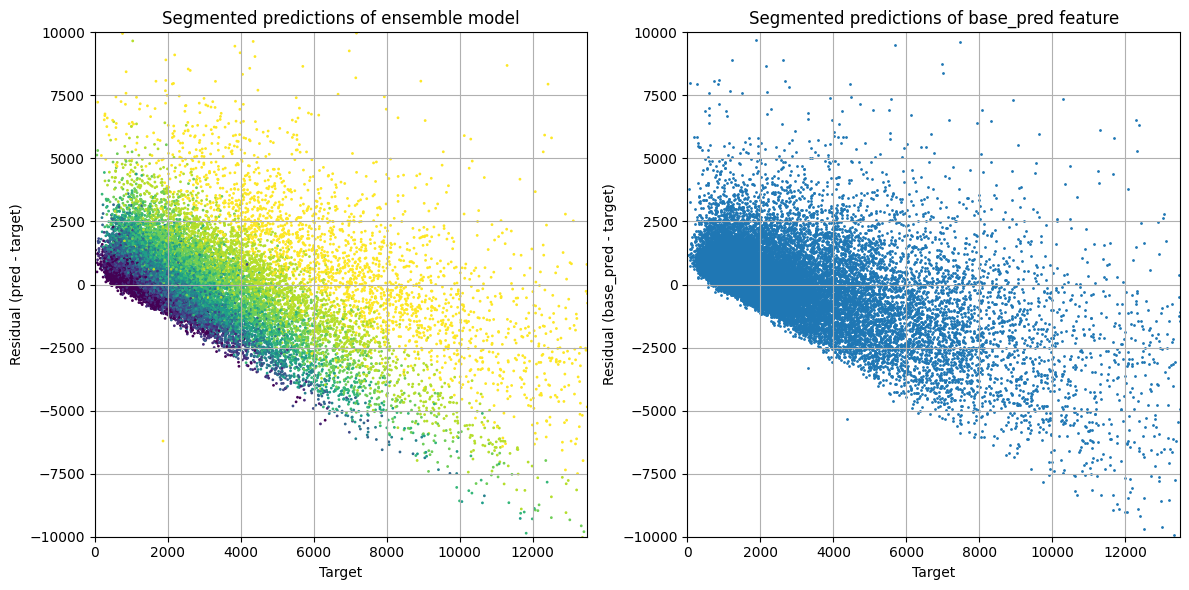

In [31]:
ensemble.visualize_predictions(x_val[all_features_ensemble], y_val)

Кажется, такой ансамбль плохо решает свою задачу, так как из-за того, что исходная модель уже имеет линейное отклонение от таргета, деление по этому признаку чаще всего не приводит к тому, что предсказания одного порядка будут примерно в той области, где распределены объекты с таким же таргетом.

In [37]:
# скор ухудшился, так что закомментировано
# x_test["base_pred"] = model_pruned.predict(x_test[all_features_pruned])
# preds = ensemble.predict(x_test[all_features_ensemble])
# sample_submission["target"] = preds
# sample_submission.to_csv("submission_ensemble.csv", index=False)

Ансамблирование не помогло, но таким с распределением ошибки можно бороться по-другому.

На графиках видно, что помимо того, что среднее отклонение линейно зависит от таргета, его разброс увеличивается с его ростом. Попробуем присвоить веса побольше объектам с большим значением таргета 

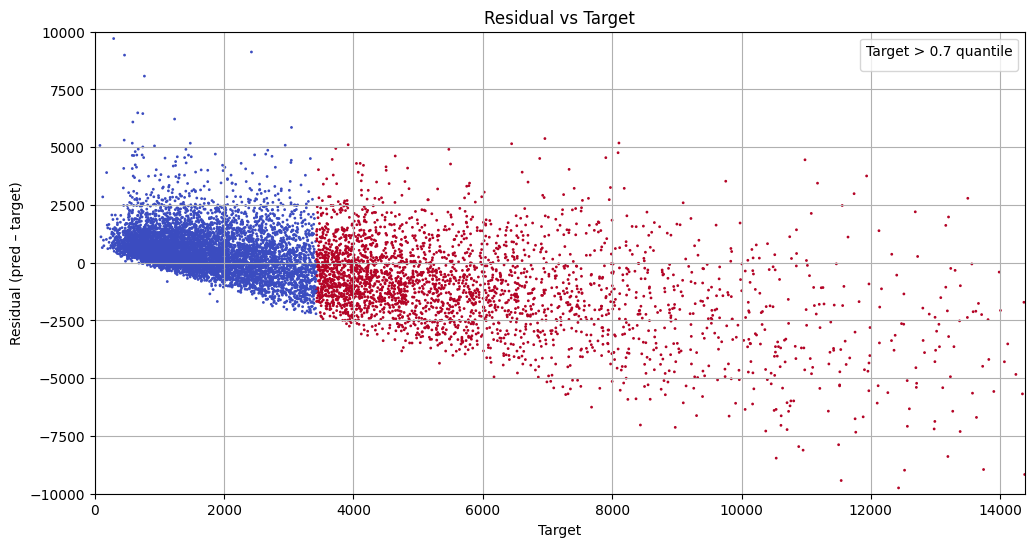

In [33]:
plt.figure(figsize=(12, 6))
x_train["target"] = y_train.values
data_to_plot = x_train.sample(10000)

ax = plt.scatter(
    data_to_plot["target"],
    data_to_plot["base_pred"] - data_to_plot["target"],
    c=data_to_plot["target"] > np.quantile(data_to_plot["target"], 0.7),
    cmap="coolwarm",
    s=1,
)


plt.xlim(0, np.quantile(data_to_plot["target"], 0.99))
plt.ylim(-10000, 10000)
plt.grid()
plt.xlabel("Target")
plt.ylabel("Residual (pred – target)")
plt.title("Residual vs Target")
plt.legend(
    loc="upper right",
    title="Target > 0.7 quantile",
)
plt.show()

На красных объектах наблюдается большой разброс.
Попробуем его уменьшить, увеличив веса объектов с большим таргетом

In [34]:
weights = np.ones(len(x_train))
weights[x_train["target"] > np.quantile(x_train["target"], 0.7)] = 1.5

In [35]:
model_weighted = lgb.LGBMRegressor(
    n_estimators=1000,
    random_state=SEED,
)

model_weighted.fit(
    x_train[all_features_pruned],
    y_train,
    eval_set=[(x_val[all_features_pruned], y_val)],
    sample_weight=weights,
    eval_metric="rmse",
    categorical_feature=cat_features_pruned,
    callbacks=[
        lgb.log_evaluation(period=5),
        lgb.early_stopping(stopping_rounds=50, verbose=True),
    ],
)

Training until validation scores don't improve for 50 rounds
[5]	valid_0's rmse: 2318.08	valid_0's l2: 5.37348e+06
[10]	valid_0's rmse: 2092.01	valid_0's l2: 4.37652e+06
[15]	valid_0's rmse: 1986.09	valid_0's l2: 3.94457e+06
[20]	valid_0's rmse: 1930.7	valid_0's l2: 3.72762e+06
[25]	valid_0's rmse: 1897.86	valid_0's l2: 3.60188e+06
[30]	valid_0's rmse: 1879.19	valid_0's l2: 3.53137e+06
[35]	valid_0's rmse: 1866.14	valid_0's l2: 3.48247e+06
[40]	valid_0's rmse: 1857.2	valid_0's l2: 3.44919e+06
[45]	valid_0's rmse: 1851.39	valid_0's l2: 3.42764e+06
[50]	valid_0's rmse: 1847.14	valid_0's l2: 3.41192e+06
[55]	valid_0's rmse: 1845.23	valid_0's l2: 3.40487e+06
[60]	valid_0's rmse: 1843.56	valid_0's l2: 3.39871e+06
[65]	valid_0's rmse: 1842.17	valid_0's l2: 3.3936e+06
[70]	valid_0's rmse: 1841.95	valid_0's l2: 3.39277e+06
[75]	valid_0's rmse: 1840.49	valid_0's l2: 3.38739e+06
[80]	valid_0's rmse: 1840.78	valid_0's l2: 3.38846e+06
[85]	valid_0's rmse: 1839.52	valid_0's l2: 3.38383e+06
[90]	val

LGBMRegressor(n_estimators=1000, random_state=0)

На валидационной выборке `RMSE` увеличился, но на целевой метрике на тестовых данных наблюдается небольшое уменьшение лосса, так что финальное предсказание будет с моделью с весами

In [36]:
pred = model_weighted.predict(x_test[all_features_pruned])
sample_submission["target"] = pred
sample_submission.to_csv("submission_weighted.csv", index=False)